# **Libraries :**

In [3]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

#Deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.callbacks import EarlyStopping

import time

import shap



# **Load dataset :**

In [4]:
data = pd.read_csv("data.csv")

data.head()


,Depth(ft),Depth(m),ROP(1 ft),ROP(1 m),weight on bit (k-lbs),weight on bit (kg),Temp Out( degF),Temp Out( degC),Temp In(degF),Temp In(degC),...,Surface Torque (KPa),Rotary Speed (rpm),Flow In (gal/min),Flow In(liters/min),Flow Out %,WH Pressure (psi),WH Pressure (KPa),H2S Floor,H2S Cellar,H2S Pits
0,85.18,25.96,56.80,17.31,0.0,0.0,93.49,34.16,90.87,32.71,...,61.57,151.09,1109.58,4200.22,101.61,-1230.69,-8485.61,-0.01,-0.03,0.31
1,86.18,26.27,61.14,18.63,0.0,0.0,93.52,34.18,90.83,32.68,...,61.57,151.09,1108.36,4195.60,101.70,-1230.69,-8485.61,-0.01,-0.04,0.31
2,87.23,26.59,18.58,5.66,0.0,0.0,94.25,34.58,90.91,32.73,...,62.12,61.54,1102.87,4174.82,96.81,-1230.69,-8485.61,-0.01,-0.03,0.30
3,88.26,26.90,38.29,11.67,0.0,0.0,94.44,34.69,91.14,32.86,...,61.85,60.23,1101.04,4167.89,96.67,-1230.69,-8485.61,0.00,-0.03,0.31
4,89.36,27.24,394.38,120.20,0.0,0.0,94.48,34.71,91.18,32.88,...,61.85,61.75,1102.46,4173.26,96.63,-1230.69,-8485.61,-0.02,-0.02,0.31


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7311 entries, 0 to 7310
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Depth(ft)              7311 non-null   float64
 1   Depth(m)               7311 non-null   float64
 2   ROP(1 ft)              7311 non-null   float64
 3   ROP(1 m)               7311 non-null   float64
 4   weight on bit (k-lbs)  7311 non-null   float64
 5   weight on bit (kg)     7311 non-null   float64
 6   Temp Out( degF)        7311 non-null   float64
 7   Temp Out( degC)        7311 non-null   float64
 8   Temp In(degF)          7311 non-null   float64
 9   Temp In(degC)          7311 non-null   float64
 10  Pit Total (bbls)       7311 non-null   float64
 11  Pit Total (m3)         7311 non-null   float64
 12  Pump Press (psi)       7311 non-null   float64
 13  Pump Press (KPa)       7311 non-null   float64
 14  Hookload (k-lbs)       7311 non-null   float64
 15  Hook

# **Correlation Matrix**

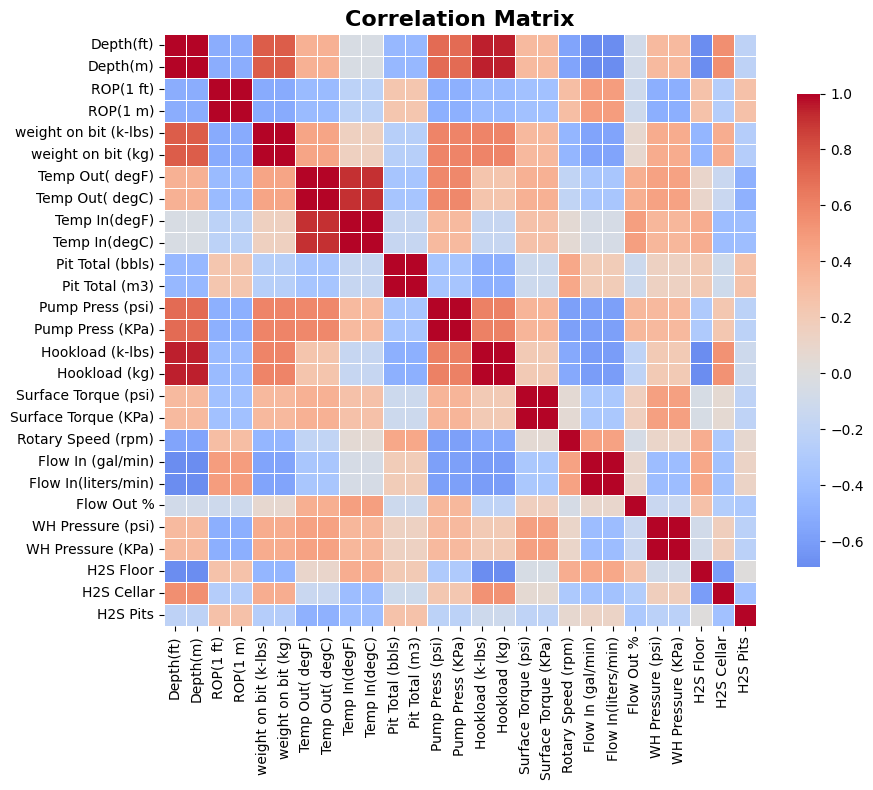

In [6]:
corr_matrix = data.select_dtypes(include=[np.number]).corr()

# Create the plot
plt.figure(figsize=(10, 8))

# Create heatmap
sns.heatmap(corr_matrix,
            cmap='coolwarm',
            center=0,
            fmt='.2f',
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

# Add title
plt.title('Correlation Matrix', fontsize=16, fontweight='bold')

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

# **Select relevant features :**

In [7]:
data = data[
    [
       'Depth(m)', 'ROP(1 m)',
       'weight on bit (kg)',
       'Temp Out( degC)', 'Temp In(degC)',
       'Pit Total (m3)', 'Pump Press (KPa)',
       'Hookload (kg)',
       'Surface Torque (KPa)', 'Rotary Speed (rpm)',
       'Flow In(liters/min)', 'Flow Out %',
       'WH Pressure (KPa)', 'H2S Floor', 'H2S Cellar', 'H2S Pits'
    ]
]


In [8]:
# --- Mechanical & Drilling Dynamics ---
data['WOB_x_RPM'] = data['weight on bit (kg)'] * data['Rotary Speed (rpm)']
data['Torque_x_RPM'] = data['Surface Torque (KPa)'] * data['Rotary Speed (rpm)']


# --- Hydraulic Effects ---
data['Flow_Delta'] = data['Flow In(liters/min)'] - (
    data['Flow In(liters/min)'] * data['Flow Out %'] / 100
)
data['Pressure_Delta'] = data['Pump Press (KPa)'] - data['WH Pressure (KPa)']
data['Hydraulic_Power_proxy'] = (
    data['Flow In(liters/min)'] * data['Pump Press (KPa)']
)

# --- Thermal Effects ---
data['Temp_Delta'] = data['Temp Out( degC)'] - data['Temp In(degC)']
data['Temp_Gradient'] = data['Temp_Delta'] / (data['Depth(m)'] + 1)

print("New engineered features added:",
      set(data.columns) - {
          'Depth(m)', 'ROP(1 m)', 'weight on bit (kg)',
          'Temp Out( degC)', 'Temp In(degC)', 'Pit Total (m3)',
          'Pump Press (KPa)', 'Hookload (kg)', 'Surface Torque (KPa)',
          'Rotary Speed (rpm)', 'Flow In(liters/min)', 'Flow Out %',
          'WH Pressure (KPa)', 'H2S Floor', 'H2S Cellar', 'H2S Pits'
      })


New engineered features added: {'Temp_Delta', 'Temp_Gradient', 'Flow_Delta', 'Torque_x_RPM', 'WOB_x_RPM', 'Pressure_Delta', 'Hydraulic_Power_proxy'}


# **Check for Missing Values and Duplicates :**

In [9]:
# Check missing values
print("Missing Values:")
print(data.isnull().sum())
print(f"\nTotal missing values: {data.isnull().sum().sum()}")

# Check for duplicate rows
duplicates = data.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

if duplicates > 0:
    print("Removing duplicates...")
    data = data.drop_duplicates()
    print(f"New shape after removing duplicates: {data.shape}")

Missing Values:
Depth(m)                 0
ROP(1 m)                 0
weight on bit (kg)       0
Temp Out( degC)          0
Temp In(degC)            0
Pit Total (m3)           0
Pump Press (KPa)         0
Hookload (kg)            0
Surface Torque (KPa)     0
Rotary Speed (rpm)       0
Flow In(liters/min)      0
Flow Out %               0
WH Pressure (KPa)        0
H2S Floor                0
H2S Cellar               0
H2S Pits                 0
WOB_x_RPM                0
Torque_x_RPM             0
Flow_Delta               0
Pressure_Delta           0
Hydraulic_Power_proxy    0
Temp_Delta               0
Temp_Gradient            0
dtype: int64

Total missing values: 0

Number of duplicate rows: 30
Removing duplicates...
New shape after removing duplicates: (7281, 23)


# **Correlation analysis :**

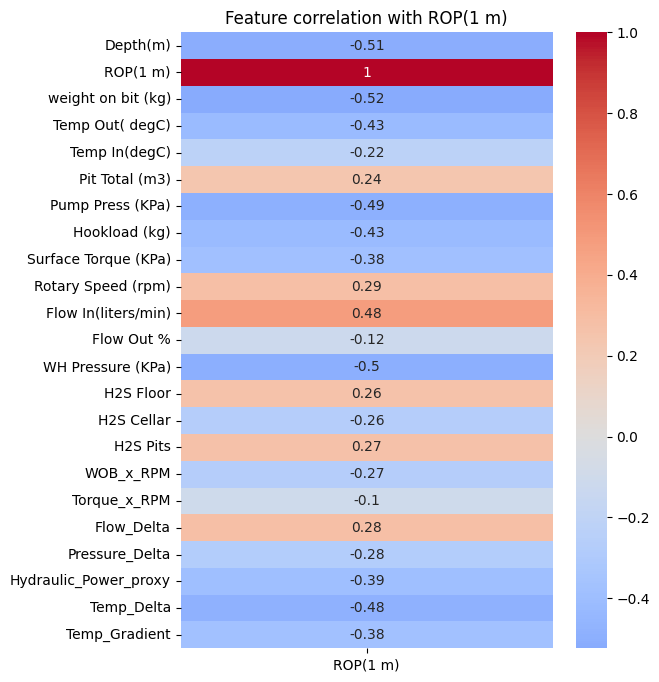

In [10]:
plt.figure(figsize=(6,8))

# Correlation of all features with the target
corr_target = data.corr()[['ROP(1 m)']]

sns.heatmap(
    corr_target,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Feature correlation with ROP(1 m)")
plt.show()


# **Outlier handling :**

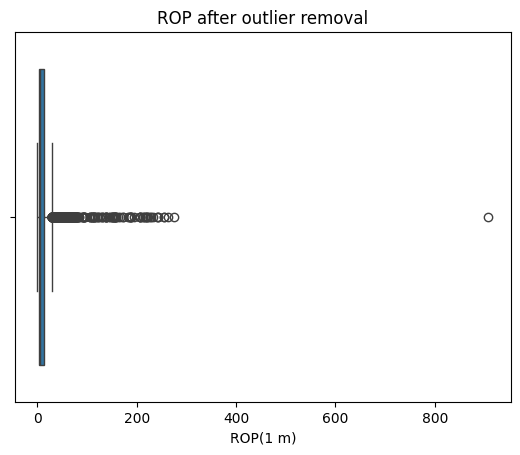

In [11]:
sns.boxplot(x=data['ROP(1 m)'])
plt.title("ROP after outlier removal")
plt.show()


In [12]:
data = data[data['ROP(1 m)'] < 800]


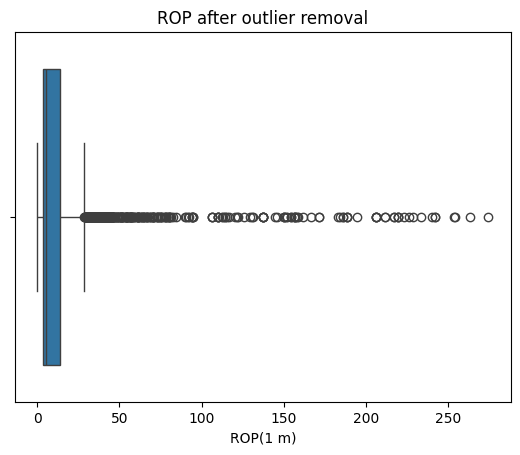

In [13]:
sns.boxplot(x=data['ROP(1 m)'])
plt.title("ROP after outlier removal")
plt.show()


# **Train / Validation / Test split :**

In [14]:
X = data.drop('ROP(1 m)', axis=1)
y = data['ROP(1 m)']

# 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# split remaining 30% into 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

X_test_error = X_test.copy()
X_train_error = X_train.copy()
X_val_error = X_val.copy()

print(X_train.shape, X_val.shape, X_test.shape)


(5096, 22) (1092, 22) (1092, 22)


# **Feature scaling :**

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

# **Part 1 :**

---



# **Models :**

**Multiple Linear Regression**

In [16]:
start_time = time.time()

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

lr_train_time = time.time() - start_time

y_pred_lr = lin_reg.predict(X_val_scaled)

print("Linear Regression")
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred_lr)))
print("MAE :", mean_absolute_error(y_val, y_pred_lr))
print("R2  :", r2_score(y_val, y_pred_lr))
print("Training time  :", lr_train_time)


Linear Regression
RMSE: 12.554365198981303
MAE : 5.458984328838445
R2  : 0.7050008200697591
Training time  : 0.009635686874389648


**GBDT (Gradient Boosting Decision Trees)**

In [17]:
start_time = time.time()

gbdt = GradientBoostingRegressor(random_state=42)
gbdt.fit(X_train_scaled, y_train)

gbdt_train_time = time.time() - start_time

y_pred_gbdt = gbdt.predict(X_val_scaled)

print("GBDT")
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred_gbdt)))
print("MAE :", mean_absolute_error(y_val, y_pred_gbdt))
print("R2  :", r2_score(y_val, y_pred_gbdt))
print("Training time  :", gbdt_train_time)


GBDT
RMSE: 9.328877098944492
MAE : 3.340183494079008
R2  : 0.8371116454677364
Training time  : 5.529600381851196


**XGBoost**

In [18]:
start_time = time.time()

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    objective='reg:squarederror',
    random_state=42
)

xgb.fit(X_train_scaled, y_train)

xgb_train_time = time.time() - start_time

y_pred_xgb = xgb.predict(X_val_scaled)

print("XGBoost")
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred_xgb)))
print("MAE :", mean_absolute_error(y_val, y_pred_xgb))
print("R2  :", r2_score(y_val, y_pred_xgb))
print("Training time  :", xgb_train_time)


XGBoost
RMSE: 8.588722803915157
MAE : 2.8604007587546394
R2  : 0.8619334522826352
Training time  : 1.592677116394043


**Random Forest Regressor**

In [19]:
start_time = time.time()

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)

rf_train_time = time.time() - start_time

y_pred_rf = rf.predict(X_val_scaled)

print("Random Forest")
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred_rf)))
print("MAE :", mean_absolute_error(y_val, y_pred_rf))
print("R2  :", r2_score(y_val, y_pred_rf))
print("Training time  :", rf_train_time)


Random Forest
RMSE: 8.854389802088923
MAE : 2.7699465201465214
R2  : 0.8532599821765078
Training time  : 51.09413552284241


**MLP Architecture**

In [20]:
mlp = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
mlp.compile(
    optimizer='adam',
    loss='mse'
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

start_time = time.time()

history_mlp = mlp.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=120,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

mlp_train_time = time.time() - start_time


Epoch 1/120
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 389.7697 - val_loss: 222.0911
Epoch 2/120
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 168.0980 - val_loss: 175.6889
Epoch 3/120
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 148.2779 - val_loss: 159.5205
Epoch 4/120
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 136.3105 - val_loss: 153.2744
Epoch 5/120
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 127.2965 - val_loss: 146.9798
Epoch 6/120
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 159.9860 - val_loss: 149.4897
Epoch 7/120
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 117.3363 - val_loss: 144.0159
Epoch 8/120
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 111.6470 - val_loss: 143.5579
Epoch 9/120
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 140.7020 - val_loss: 143.0501
Epoch 10/120
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 124.0345 - val_loss: 141.2406
Epoch 11/120
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 108.6593 - val_loss: 140.09

In [22]:
y_pred_mlp = mlp.predict(X_test_scaled).flatten()
MSE_MLP = mean_squared_error(y_test, y_pred_mlp)
RMSE_MLP = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
MAE_MLP = mean_absolute_error(y_test, y_pred_mlp)
R2_MLP = r2_score(y_test, y_pred_mlp)

print("MLP")
print("MSE :", mean_squared_error(y_test, y_pred_mlp))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_mlp)))
print("MAE :", mean_absolute_error(y_test, y_pred_mlp))
print("R2  :", r2_score(y_test, y_pred_mlp))
print("Training time  :", mlp_train_time)


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MLP
MSE : 113.4110563923087
RMSE: 10.649462727870768
MAE : 3.5700435789622667
R2  : 0.723678536463936
Training time  : 54.72724890708923


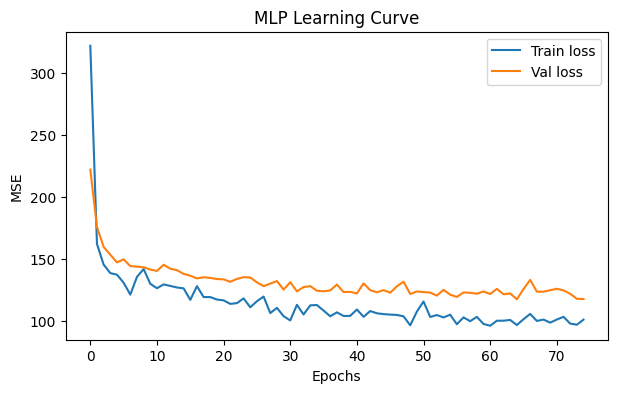

In [23]:
plt.figure(figsize=(7,4))
plt.plot(history_mlp.history['loss'], label='Train loss')
plt.plot(history_mlp.history['val_loss'], label='Val loss')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.title('MLP Learning Curve')
plt.legend()
plt.show()


# **Comparative evaluation table :**

In [24]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "GBDT", "XGBoost", "MLP"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_val, y_pred_lr)),
        np.sqrt(mean_squared_error(y_val, y_pred_rf)),
        np.sqrt(mean_squared_error(y_val, y_pred_gbdt)),
        np.sqrt(mean_squared_error(y_val, y_pred_xgb)),
        np.sqrt(mean_squared_error(y_test, y_pred_mlp))
    ],
    "MAE": [
        mean_absolute_error(y_val, y_pred_lr),
        mean_absolute_error(y_val, y_pred_rf),
        mean_absolute_error(y_val, y_pred_gbdt),
        mean_absolute_error(y_val, y_pred_xgb),
        mean_absolute_error(y_test, y_pred_mlp)
    ],
    "R2": [
        r2_score(y_val, y_pred_lr),
        r2_score(y_val, y_pred_rf),
        r2_score(y_val, y_pred_gbdt),
        r2_score(y_val, y_pred_xgb),
        r2_score(y_test, y_pred_mlp)
    ],

    "Train_Time_sec": [
        lr_train_time,
        rf_train_time,
        gbdt_train_time,
        xgb_train_time,
        mlp_train_time
    ]
})

results


,Model,RMSE,MAE,R2,Train_Time_sec
0,Linear Regression,12.554365,5.458984,0.705001,0.009636
1,Random Forest,8.854390,2.769947,0.853260,51.094136
2,GBDT,9.328877,3.340183,0.837112,5.529600
3,XGBoost,8.588723,2.860401,0.861933,1.592677
4,MLP,10.649463,3.570044,0.723679,54.727249


# **Best model**

In [25]:
# 1. Combine train and validation sets
X_train_val_scaled = np.concatenate([X_train_scaled, X_val_scaled])
y_train_val = np.concatenate([y_train, y_val])

In [26]:
# 1. Define the best model
best_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# 2. Train on Train + Validation
best_model.fit(X_train_val_scaled, y_train_val)

# 3. Predict on Test set
y_test_pred = best_model.predict(X_test_scaled)

# 4. Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("Final Test Set Performance (XGBoost):")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

Final Test Set Performance (XGBoost):
RMSE: 9.5991
MAE:  2.9848
R²:   0.7755


# **Part 2 :**

---



# **LSTM :**

In [27]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [28]:
# Define target
target = 'ROP(1 m)'

# Define features (everything except the target)
features = [
    'Depth(m)', 'weight on bit (kg)', 'Temp Out( degC)',
    'Temp In(degC)', 'Pit Total (m3)', 'Pump Press (KPa)',
    'Hookload (kg)', 'Surface Torque (KPa)', 'Rotary Speed (rpm)',
    'Flow In(liters/min)', 'Flow Out %', 'WH Pressure (KPa)',
    'H2S Floor', 'H2S Cellar', 'H2S Pits',
    'WOB_x_RPM', 'Torque_x_RPM', 'Flow_Delta', 'Pressure_Delta',
    'Hydraulic_Power_proxy', 'Temp_Delta', 'Temp_Gradient'
]

# Your existing code (unchanged)
data = data.sort_values("Depth(m)").reset_index(drop=True)

X = data[features].values
y = data[target].values.reshape(-1, 1)


In [29]:
train_size = int(0.7 * len(X))
val_size   = int(0.85 * len(X))

X_train, X_val, X_test = X[:train_size], X[train_size:val_size], X[val_size:]
y_train, y_val, y_test = y[:train_size], y[train_size:val_size], y[val_size:]


In [30]:
X_scaler = StandardScaler()
#y_scaler = MinMaxScaler()

X_train = X_scaler.fit_transform(X_train)
X_val   = X_scaler.transform(X_val)
X_test  = X_scaler.transform(X_test)


In [31]:
def create_sequences(X, y, n_steps):
    X_seq, y_seq = [], []
    for i in range(n_steps, len(X)):
        X_seq.append(X[i-n_steps:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

n_steps = 10  # you can try 5, 10, 20

X_train_seq, y_train_seq = create_sequences(X_train, y_train, n_steps)
X_val_seq, y_val_seq     = create_sequences(X_val, y_val, n_steps)
X_test_seq, y_test_seq   = create_sequences(X_test, y_test, n_steps)


In [32]:
model = Sequential([
    LSTM(64, activation='tanh', return_sequences=True,
         input_shape=(n_steps, X_train_seq.shape[2])),
    Dropout(0.2),

    LSTM(32, activation='tanh'),
    Dropout(0.2),

    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,721 (135.63 KB)

 Trainable params: 34,721 (135.63 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
)

start_time = time.time()

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

lstm_train_time = time.time() - start_time


Epoch 1/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 678.1532 - val_loss: 1.5456
Epoch 2/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 472.0757 - val_loss: 1.3554
Epoch 3/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 520.0509 - val_loss: 1.3084
Epoch 4/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 478.3992 - val_loss: 1.2663
Epoch 5/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 361.7578 - val_loss: 1.2255
Epoch 6/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 357.3686 - val_loss: 1.1246
Epoch 7/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 328.9103 - val_loss: 1.2744
Epoch 8/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 419.5830 - val_loss: 1.1501
Epoch 9/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 325.1841 - val_loss: 1.1493
Epoch 10/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 326.2806 - val_loss: 1.0531
Epoch 11/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 295.5468 - val_loss: 1.1473
Epoch 12/30
159/159

In [34]:
y_pred_scaled = model.predict(X_test_seq)

mse_LSTM  = mean_squared_error(y_test_seq, y_pred_scaled)
rmse_LSTM = np.sqrt(mse_LSTM)
mae_LSTM  = mean_absolute_error(y_test_seq, y_pred_scaled)
r2_LSTM   = r2_score(y_test_seq, y_pred_scaled)

print(f"MSE  : {mse_LSTM:.4f}")
print(f"RMSE : {rmse_LSTM:.4f}")
print(f"MAE  : {mae_LSTM:.4f}")
print(f"R²   : {r2_LSTM:.4f}")
print("Training time  :", lstm_train_time)

34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
MSE  : 2.2021
RMSE : 1.4839
MAE  : 1.0521
R²   : 0.1243
Training time  : 87.51455426216125


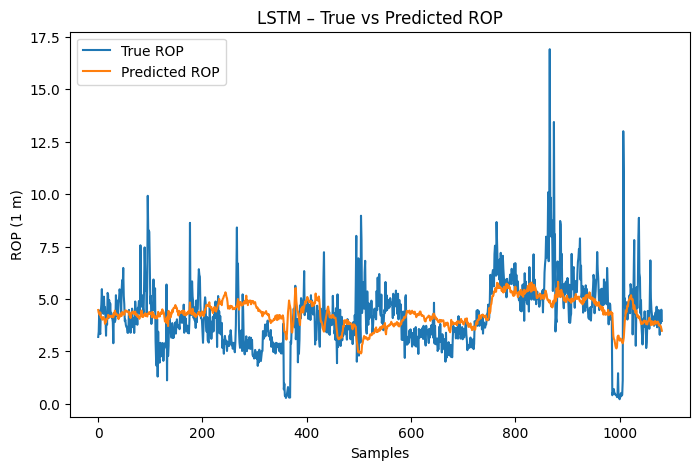

In [35]:
plt.figure(figsize=(8,5))
plt.plot(y_test_seq, label='True ROP')
plt.plot(y_pred_scaled, label='Predicted ROP')
plt.xlabel("Samples")
plt.ylabel("ROP (1 m)")
plt.legend()
plt.title("LSTM – True vs Predicted ROP")
plt.show()


**Classical models :**

In [36]:
start_time = time.time()

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

lr_train_time = time.time() - start_time

y_pred_lr_temp = lin_reg.predict(X_val)

print("Linear Regression")
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred_lr_temp)))
print("MAE :", mean_absolute_error(y_val, y_pred_lr_temp))
print("R2  :", r2_score(y_val, y_pred_lr_temp))
print("Training time  :", lr_train_time)
print("---------------------------------")

start_time = time.time()

gbdt = GradientBoostingRegressor(random_state=42)
gbdt.fit(X_train, y_train)

gbdt_train_time = time.time() - start_time

y_pred_gbdt_temp = gbdt.predict(X_val)

print("GBDT")
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred_gbdt_temp)))
print("MAE :", mean_absolute_error(y_val, y_pred_gbdt_temp))
print("R2  :", r2_score(y_val, y_pred_gbdt_temp))
print("Training time  :", gbdt_train_time)
print("---------------------------------")

start_time = time.time()

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    objective='reg:squarederror',
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_train_time = time.time() - start_time

y_pred_xgb_temp = xgb.predict(X_val)

print("XGBoost")
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred_xgb_temp)))
print("MAE :", mean_absolute_error(y_val, y_pred_xgb_temp))
print("R2  :", r2_score(y_val, y_pred_xgb_temp))
print("Training time  :", xgb_train_time)
print("---------------------------------")

start_time = time.time()

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_train_time = time.time() - start_time

y_pred_rf_temp = rf.predict(X_val)

print("Random Forest")
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred_rf_temp)))
print("MAE :", mean_absolute_error(y_val, y_pred_rf_temp))
print("R2  :", r2_score(y_val, y_pred_rf_temp))
print("Training time  :", rf_train_time)





Linear Regression
RMSE: 15.173835090407197
MAE : 13.866960255018386
R2  : -174.04614092541655
Training time  : 0.006996631622314453
---------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


GBDT
RMSE: 1.2356513963900264
MAE : 0.9350078332961148
R2  : -0.1607902448027505
Training time  : 4.3537116050720215
---------------------------------
XGBoost
RMSE: 1.3042017335941263
MAE : 0.9925132014026572
R2  : -0.2931573344928051
Training time  : 3.1491777896881104
---------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest
RMSE: 1.659513717701026
MAE : 1.2763312881562856
R2  : -1.0937436846832322
Training time  : 35.48561358451843


# **Comparative evaluation table :(time)**

In [37]:
results_temp = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "GBDT", "XGBoost", "LSTM"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_val, y_pred_lr_temp)),
        np.sqrt(mean_squared_error(y_val, y_pred_rf_temp)),
        np.sqrt(mean_squared_error(y_val, y_pred_gbdt_temp)),
        np.sqrt(mean_squared_error(y_val, y_pred_xgb_temp)),
        np.sqrt(mean_squared_error(y_test_seq, y_pred_scaled))
    ],
    "MAE": [
        mean_absolute_error(y_val, y_pred_lr_temp),
        mean_absolute_error(y_val, y_pred_rf_temp),
        mean_absolute_error(y_val, y_pred_gbdt_temp),
        mean_absolute_error(y_val, y_pred_xgb_temp),
        mean_absolute_error(y_test_seq, y_pred_scaled)
    ],
    "R2": [
        r2_score(y_val, y_pred_lr_temp),
        r2_score(y_val, y_pred_rf_temp),
        r2_score(y_val, y_pred_gbdt_temp),
        r2_score(y_val, y_pred_xgb_temp),
        r2_score(y_test_seq, y_pred_scaled)
    ],

    "Train_Time_sec": [
        lr_train_time,
        rf_train_time,
        gbdt_train_time,
        xgb_train_time,
        mlp_train_time
    ]
})

results_temp


,Model,RMSE,MAE,R2,Train_Time_sec
0,Linear Regression,15.173835,13.866960,-174.046141,0.006997
1,Random Forest,1.659514,1.276331,-1.093744,35.485614
2,GBDT,1.235651,0.935008,-0.160790,4.353712
3,XGBoost,1.304202,0.992513,-0.293157,3.149178
4,LSTM,1.483948,1.052125,0.124318,54.727249


# **HYBRID MODEL :**

**Methode 01**

In [38]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping


In [39]:
TIME_STEPS = 10

inputs = Input(shape=(TIME_STEPS, X_train.shape[1]))

x = LSTM(64, return_sequences=False)(inputs)
embedding = Dense(32, activation="relu", name="embedding")(x)

output = Dense(1)(embedding)

lstm_model = Model(inputs, output)

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

lstm_model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 10, 22)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,385 (95.25 KB)

 Trainable params: 24,385 (95.25 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

start_time = time.time()

lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

hyb1_train_time = time.time() - start_time


Epoch 1/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 859.2437 - val_loss: 12.5234
Epoch 2/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 329.1927 - val_loss: 7.5746
Epoch 3/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 246.1086 - val_loss: 4.6443
Epoch 4/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 184.8021 - val_loss: 4.4126
Epoch 5/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 194.0505 - val_loss: 3.9460
Epoch 6/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 177.8547 - val_loss: 4.2778
Epoch 7/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 135.4971 - val_loss: 4.0614
Epoch 8/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 126.8700 - val_loss: 3.2499
Epoch 9/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 135.5083 - val_loss: 3.4998
Epoch 10/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 119.4830 - val_loss: 3.0223
Epoch 11/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 120.4915 - val_loss: 3.4510
Epoch 12/50
159/159 ━━━━━━

In [41]:
embedding_model = Model(
    inputs=lstm_model.input,
    outputs=lstm_model.get_layer("embedding").output
)

emb_train = embedding_model.predict(X_train_seq)
emb_val   = embedding_model.predict(X_val_seq)
emb_test  = embedding_model.predict(X_test_seq)


159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [42]:
X_train_gbdt = np.hstack([
    X_train[TIME_STEPS:TIME_STEPS + len(emb_train)],
    emb_train
])

X_val_gbdt = np.hstack([
    X_val[TIME_STEPS:TIME_STEPS + len(emb_val)],
    emb_val
])

X_test_gbdt = np.hstack([
    X_test[TIME_STEPS:TIME_STEPS + len(emb_test)],
    emb_test
])


In [43]:
y_train_gbdt = y_train[TIME_STEPS:TIME_STEPS + len(emb_train)]
y_val_gbdt   = y_val[TIME_STEPS:TIME_STEPS + len(emb_val)]
y_test_gbdt  = y_test[TIME_STEPS:TIME_STEPS + len(emb_test)]


In [44]:
gbdt = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

start_time = time.time()

gbdt.fit(X_train_gbdt, y_train_gbdt)

hyb1_train_time = hyb1_train_time +  (time.time() - start_time)


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


In [45]:
y_pred = gbdt.predict(X_test_gbdt)

mae_HYB1  = mean_absolute_error(y_test_gbdt, y_pred)
mse_HYB1  = mean_squared_error(y_test_gbdt, y_pred)
rmse_HYB1 = np.sqrt(mse_HYB1)
r2_HYB1   = r2_score(y_test_gbdt, y_pred)

print(f"MAE  : {mae_HYB1:.4f}")
print(f"MSE  : {mse_HYB1:.4f}")
print(f"RMSE : {rmse_HYB1:.4f}")
print(f"R²   : {r2_HYB1:.4f}")
print("Training time  :", hyb1_train_time)

MAE  : 1.3789
MSE  : 3.6392
RMSE : 1.9077
R²   : -0.4472
Training time  : 72.19353151321411


**Methode 02**

In [46]:
lstm_pred_model = tf.keras.Sequential([
    LSTM(64, input_shape=(TIME_STEPS, X_train.shape[1])),
    Dense(1)
])

lstm_pred_model.compile(
    optimizer="adam",
    loss="mse"
)

start_time = time.time()

lstm_pred_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=40,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

hyb2_train_time = time.time() - start_time


Epoch 1/40


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


159/159 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 759.9764 - val_loss: 3.9897
Epoch 2/40
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 423.9149 - val_loss: 3.2011
Epoch 3/40
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 338.9472 - val_loss: 2.6804
Epoch 4/40
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 313.8134 - val_loss: 1.9848
Epoch 5/40
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 240.6357 - val_loss: 2.2365
Epoch 6/40
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 293.7036 - val_loss: 2.8283
Epoch 7/40
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 309.3938 - val_loss: 2.6303
Epoch 8/40
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 285.6515 - val_loss: 2.3399
Epoch 9/40
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 263.1033 - val_loss: 1.9911


In [47]:
y_train_lstm = lstm_pred_model.predict(X_train_seq).ravel()
y_val_lstm   = lstm_pred_model.predict(X_val_seq).ravel()
y_test_lstm  = lstm_pred_model.predict(X_test_seq).ravel()


159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [48]:
gbdt_tab = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

start_time = time.time()

gbdt_tab.fit(
    X_train[TIME_STEPS:TIME_STEPS + len(y_train_lstm)],
    y_train_seq
)

hyb2_train_time = hyb2_train_time +  (time.time() - start_time)


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


In [49]:
y_train_gbdt = gbdt_tab.predict(
    X_train[TIME_STEPS:TIME_STEPS + len(y_train_lstm)]
)

y_val_gbdt = gbdt_tab.predict(
    X_val[TIME_STEPS:TIME_STEPS + len(y_val_lstm)]
)

y_test_gbdt = gbdt_tab.predict(
    X_test[TIME_STEPS:TIME_STEPS + len(y_test_lstm)]
)


In [50]:
X_train_stack = np.column_stack([y_train_lstm, y_train_gbdt])
X_val_stack   = np.column_stack([y_val_lstm, y_val_gbdt])
X_test_stack  = np.column_stack([y_test_lstm, y_test_gbdt])


In [51]:
stacker = tf.keras.Sequential([
    Dense(16, activation="relu", input_shape=(2,)),
    Dense(1)
])

stacker.compile(
    optimizer="adam",
    loss="mse"
)

start_time = time.time()

stacker.fit(
    X_train_stack, y_train_seq,
    validation_data=(X_val_stack, y_val_seq),
    epochs=50,
    batch_size=16,
    verbose=1
)

hyb2_train_time = hyb2_train_time +  (time.time() - start_time)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


318/318 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1064.4304 - val_loss: 1.5448
Epoch 2/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 156.0417 - val_loss: 1.3574
Epoch 3/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 57.3136 - val_loss: 1.1334
Epoch 4/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 34.6223 - val_loss: 1.1005
Epoch 5/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 27.7758 - val_loss: 1.1016
Epoch 6/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 24.9337 - val_loss: 1.0934
Epoch 7/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 26.6294 - val_loss: 1.0874
Epoch 8/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 28.8225 - val_loss: 1.0867
Epoch 9/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 25.9416 - val_loss: 1.0874
Epoch 10/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 27.9946 - val_loss: 1.0822
Epoch 11/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 27.9591 - val_loss: 1.2178
Epoch 12/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/s

In [52]:
y_pred_stack = stacker.predict(X_test_stack).ravel()

mae_HYB2  = mean_absolute_error(y_test_seq, y_pred_stack)
mse_HYB2  = mean_squared_error(y_test_seq, y_pred_stack)
rmse_HYB2 = np.sqrt(mean_squared_error(y_test_seq, y_pred_stack))
r2_HYB2   = r2_score(y_test_seq, y_pred_stack)

print("MAE  :", mae_HYB2)
print("MSE  :", mse_HYB2)
print("RMSE :", rmse_HYB2)
print("R²   :", r2_HYB2)
print("Training time  :", hyb2_train_time)

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
MAE  : 1.4226296010029513
MSE  : 4.665738944181842
RMSE : 2.1600321627656016
R²   : -0.8553656906623537
Training time  : 71.42349195480347


**Mthode 03**

In [53]:
alpha = 0.6   # à ajuster


In [54]:
y_pred_weighted = alpha * y_test_lstm + (1 - alpha) * y_test_gbdt


In [55]:
mae_HYB3  = mean_absolute_error(y_test_seq, y_pred_weighted)
mse_HYB3  = mean_squared_error(y_test_seq, y_pred_weighted)
rmse_HYB3 = np.sqrt(mean_squared_error(y_test_seq, y_pred_weighted))
r2_HYB3   = r2_score(y_test_seq, y_pred_weighted)

hyb3_train_time = lstm_train_time + gbdt_train_time

print("MAE  :", mae_HYB3)
print("MSE  :", mse_HYB3)
print("RMSE :", mse_HYB3)
print("R²   :", r2_HYB3)
print("Training time  :", hyb3_train_time)


MAE  : 1.4247143257682657
MSE  : 3.7707040819703406
RMSE : 3.7707040819703406
R²   : -0.4994484404345607
Training time  : 91.86826586723328


# **Analyse d’erreur**

# **Feature importance :**

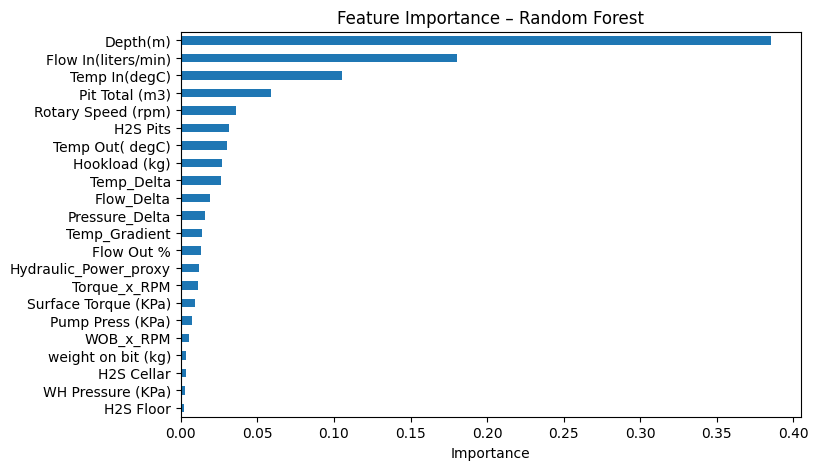

In [59]:
X_train_df = pd.DataFrame(X_train_error, columns=features)

importances = pd.Series(
    rf.feature_importances_,
    index=X_train_df.columns
).sort_values(ascending=True)

plt.figure(figsize=(8,5))
importances.plot(kind="barh")
plt.title("Feature Importance – Random Forest")
plt.xlabel("Importance")
plt.show()


In [56]:
def add_model_result(df, model_name, rmse, mae, r2, Train_Time_sec):
    return pd.concat([
        df,
        pd.DataFrame([{
            "Model": model_name,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2,
            "Train_Time_sec": Train_Time_sec
        }])
    ], ignore_index=True)


In [57]:
results_temp = add_model_result(results_temp, "Hybrid-1", rmse_HYB1, mae_HYB1, r2_HYB1, hyb1_train_time)
results_temp = add_model_result(results_temp, "Hybrid-2", rmse_HYB2, mae_HYB2, r2_HYB2, hyb2_train_time)
results_temp = add_model_result(results_temp, "Hybrid-3", rmse_HYB3, mae_HYB3, r2_HYB3, hyb3_train_time)


In [58]:
results_temp

,Model,RMSE,MAE,R2,Train_Time_sec
0,Linear Regression,15.173835,13.866960,-174.046141,0.006997
1,Random Forest,1.659514,1.276331,-1.093744,35.485614
2,GBDT,1.235651,0.935008,-0.160790,4.353712
3,XGBoost,1.304202,0.992513,-0.293157,3.149178
4,LSTM,1.483948,1.052125,0.124318,54.727249
5,Hybrid-1,1.907667,1.378871,-0.447152,72.193532
6,Hybrid-2,2.160032,1.422630,-0.855366,71.423492
7,Hybrid-3,1.941830,1.424714,-0.499448,91.868266
